## Amazon and Yelp Reviews

### Package Imports

In [1]:
%pip install nltk
%pip install spacy

import pandas as pd
import nltk
import spacy
nltk.download("all")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |

True

### Data Importing

In [2]:
review_data=pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Amazon_Yelp_Reviews/Review_Data.csv")
review_data.sample(10)

,Id,Review,Sentiment
286,287,I wouldn't recommend buying this product.,0
1088,1089,Omelets are to die for!,1
455,456,Not good when wearing a hat or sunglasses.,0
910,911,"Good show, Samsung.",1
1375,1376,Best tacos in town by far!!,1
593,594,Easy to use.,1
1847,1848,"In fact I'm going to round up to 4 stars, just...",1
640,641,"Performed awful -- muffled, tinny incoming sou...",0
619,620,Worked very well paired with a Treo 700w and a...,1
1207,1208,The WORST EXPERIENCE EVER.,0


### Preprocessing

In [3]:
contra_Expan_Dict = {"ain`t": "am not","aren`t": "are not","can`t": "cannot","can`t`ve": "cannot have","`cause": "because",
"could`ve": "could have","couldn`t": "could not","couldn`t`ve": "could not have","didn`t": "did not",
"doesn`t": "does not","don`t": "do not","hadn`t": "had not","hadn`t`ve": "had not have","hasn`t": "has not",
"haven`t": "have not","he`d": "he would","he`d`ve": "he would have","he`ll": "he will","he`ll`ve": "he will have",
"he`s": "he is","how`d": "how did","how`d`y": "how do you","how`ll": "how will",
"how`s": "how does","i`d": "i would","i`d`ve": "i would have","i`ll": "i will","i`ll`ve": "i will have","i`m": "i am",
"i`ve": "i have","isn`t": "is not","it`d": "it would","it`d`ve": "it would have","it`ll": "it will","it`ll`ve": "it will have",
"it`s": "it is","let`s": "let us","ma`am": "madam","mayn`t": "may not","might`ve": "might have","mightn`t": "might not",
"mightn`t`ve": "might not have","must`ve": "must have","mustn`t": "must not","mustn`t`ve": "must not have","needn`t": "need not","needn`t`ve": "need not have",
"o`clock": "of the clock","oughtn`t": "ought not","oughtn`t`ve": "ought not have","shan`t": "shall not",
"sha`n`t": "shall not","shan`t`ve": "shall not have","she`d": "she would",
"she`d`ve": "she would have","she`ll": "she will","she`ll`ve": "she will have",
"she`s": "she is","should`ve": "should have","shouldn`t": "should not","shouldn`t`ve": "should not have","so`ve": "so have","so`s": "so is",
"that`d": "that would","that`d`ve": "that would have","that`s": "that is","there`d": "there would","there`d`ve": "there would have","there`s": "there is",
"they`d": "they would","they`d`ve": "they would have","they`ll": "they will","they`ll`ve": "they will have","they`re": "they are","they`ve": "they have",
"to`ve": "to have","wasn`t": "was not"," u ": " you "," ur ": " your "," n ": " and ","won`t": "would not",
"dis": "this","bak": "back","brng": "bring"}

def expanded_form(x):
    if x in contra_Expan_Dict.keys():
        return(contra_Expan_Dict[x])
    else:
        return(x)

from spacy.lang.en.stop_words import STOP_WORDS as spacy_stopwords
spacy_stopwords.update({"would", "rt","like", "ha", "lol", "need", "do"})

import re
def clean_with_re(x):
    x=str(x)
    x=re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'," ", x) #Remove URLs
    x=re.sub(r'[^\w ]+', "", x) # Remove Punctuation-1
    x=re.sub(r"[,!@&\'?\.$%_]"," ", x) # Remove Punctuation-2
    x=re.sub(r"\d+"," ", x) #Remove digits
    return(x)

spacy_model = spacy.load('en_core_web_sm')

def pre_processing(input_data, text_col):
    input_data["text_col_clean"]=input_data[text_col].apply(lambda x:str(x).lower())  # Lowercase Conversion
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[expanded_form(t) for t in str(x).split()])  # Expanding Contractions
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])  # Stopword Removal 
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:clean_with_re(x))  # Cleaning using regex
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:" ".join([t.lemma_ for t in spacy_model(str(x))])) # Lemmatization (Conversion to base form)
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in str(x).split() if t not in spacy_stopwords ])  # Stopword Removal again after lemmatization
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x: " ".join(x) )  # Joining the list back to string
    print(input_data[[text_col,"text_col_clean"]])     # this will print: review_data[["Review", "test_col_clean"]]

In [4]:
pre_processing(input_data=review_data, text_col="Review")

                                                 Review  \
0     So there is no way for me to plug it in here i...   
1                           Good case, Excellent value.   
2                                Great for the jawbone.   
3     Tied to charger for conversations lasting more...   
4                                     The mic is great.   
...                                                 ...   
1995  I think food should have flavor and texture an...   
1996                           Appetite instantly gone.   
1997  Overall I was not impressed and would not go b...   
1998  The whole experience was underwhelming, and I ...   
1999  Then, as if I hadn't wasted enough of my life ...   

                                         text_col_clean  
0                                    way plug converter  
1                             good case excellent value  
2                                         great jawbone  
3         tie charger conversation minutesmajor problem  
4

### Word Cloud

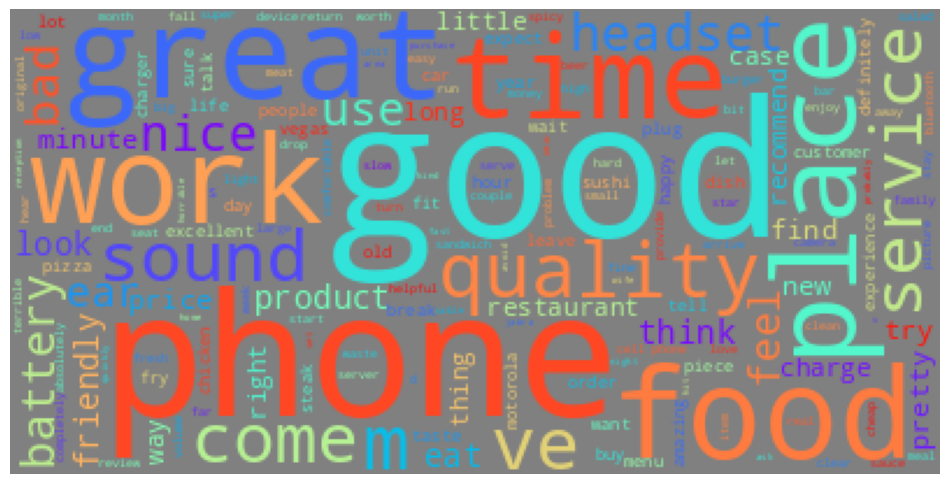

In [5]:
#!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

final_text="".join(review_data["text_col_clean"])
len(final_text)

plt.figure(figsize = (12, 12), facecolor = None)
wc=WordCloud(colormap='rainbow', background_color="grey").generate(final_text)
plt.imshow(wc)
plt.axis("off")
plt.show()

### Document Term Matrix

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

countvec1 = CountVectorizer(min_df= 2)   # keep only words having minimum word freq=2 to reduce sparsity
dtm_v1 = pd.DataFrame(countvec1.fit_transform(review_data['text_col_clean']).toarray(), columns=countvec1.get_feature_names_out(), index=None)
print(dtm_v1.shape)
dtm_v1

(2000, 982)


,ability,able,absolutely,accept,access,acknowledge,activate,actually,adapter,add,...,worst,worth,worthless,worthwhile,wow,wrap,wrong,year,yummy,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Sentiment Analysis

#### Features, Target, Train and Test Data

In [8]:
review_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Id              2000 non-null   int64
 1   Review          2000 non-null   str  
 2   Sentiment       2000 non-null   int64
 3   text_col_clean  2000 non-null   str  
dtypes: int64(2), str(2)
memory usage: 62.6 KB


In [9]:
review_data

,Id,Review,Sentiment,text_col_clean
0,1,So there is no way for me to plug it in here i...,0,way plug converter
1,2,"Good case, Excellent value.",1,good case excellent value
2,3,Great for the jawbone.,1,great jawbone
3,4,Tied to charger for conversations lasting more...,0,tie charger conversation minutesmajor problem
4,5,The mic is great.,1,mic great
...,...,...,...,...
1995,1996,I think food should have flavor and texture an...,0,think food flavor texture lack
1996,1997,Appetite instantly gone.,0,appetite instantly
1997,1998,Overall I was not impressed and would not go b...,0,overall impressed
1998,1999,"The whole experience was underwhelming, and I ...",0,experience underwhelming think ninja sushi time


In [10]:
review_data['Sentiment'].value_counts()

# we need not to remove neutral class as there is only 2 classes positive(1) and negative(0)

Sentiment
0    1000
1    1000
Name: count, dtype: int64

In [17]:
# adding target variable to dtm_v1
dtm_v1['sentiment_label']=review_data['Sentiment'] 

In [18]:
from sklearn.model_selection import train_test_split

X=dtm_v1.drop(['sentiment_label'], axis=1)
y=dtm_v1['sentiment_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=33)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1600, 982)
(1600,)
(400, 982)
(400,)


#### Naive Bayes Model

In [19]:
from sklearn.naive_bayes import MultinomialNB
senti_model_Amazon = MultinomialNB()
senti_model_Amazon.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
print("Train Accuracy", senti_model_Amazon.score(X_train,y_train))
print("Test Accuracy", senti_model_Amazon.score(X_test,y_test))

# Overfitting is observed as train accuracy is very high compared to test accuracy.

Train Accuracy 0.89625
Test Accuracy 0.81


In [ ]:
# Hyperparameter Tuning to reduce overfitting
'''
Fine-tune alpha - Additive (Laplace/Lidstone) smoothing parameter (0 for no smoothing).
P(W*|Y=1) = P(W*,Y=1)/P(Y=1)
What if W* is not present at training?
P(W*|Y=1)=Freq of W* present in class y=1 / Freq of class1
P(W*|Y=1)= 0/Freq of class1
Then we may need to add an alpha to both numerator and denominator
P(W*|Y=1) = (P(W*,Y=1)+alpha)/(P(Y=1)+(total classes)*alpha)
If alpha is too low or zero ==> Overfitting on train data
If alpha is too high ==> Then ignoring too much of training data - Underfitting
'''
senti_model_Amazon = MultinomialNB(alpha=100)
senti_model_Amazon.fit(X_train, y_train)
print("Train Accuracy", senti_model_Amazon.score(X_train,y_train))
print("Test Accuracy", senti_model_Amazon.score(X_test,y_test))

Train Accuracy 0.8075
Test Accuracy 0.7625


In [ ]:
#Prediction
pred_sentiment=senti_model_Amazon.predict(X_test)
print(pred_sentiment)

[0 1 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0
 0 0 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 1 0 1
 0 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 1 0 0 1 1 1 1
 1 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 1
 0 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0
 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0
 1 1 0 0 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1
 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0
 1 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 0 0 1
 0 0 1 1 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 0
 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0]


#### Predicting for new data points

In [20]:
t1 ="Disappointed with the quality of the product. They need to add more value into it "
t2 ="Never order a product from here. You will regret it. "
t3 = "This restaurent is super good. I am a big fan of their menu "
tweet_list=[t1,t2,t3]

new_comment= pd.DataFrame({"text":tweet_list})

#Spelling Correction & Pre-processing
from textblob import TextBlob
new_comment["text_corrected"]=new_comment["text"].apply(lambda x:"".join(TextBlob(x).correct()))
pre_processing(input_data=new_comment, text_col="text_corrected")

                                      text_corrected  \
0  Disappointed with the quality of the product. ...   
1  Never order a product from here. You will regr...   
2  His restaurant is super good. I am a big fan o...   

                         text_col_clean  
0  disappoint quality product add value  
1                  order product regret  
2    restaurant super good big fan menu  


In [ ]:
countvec = CountVectorizer()
dtm_newcomment = pd.DataFrame(countvec.fit_transform(new_comment['text_col_clean']).toarray(), columns=countvec.get_feature_names_out(), index=None)
#print(dtm_newcomment)

#Now we need to fetch all the columns from the original DTM and fill them with zeros. Fill "really" and "amazed" with 1.

dtm_v2=dtm_v1.drop(["sentiment_label"],axis=1)
dtm_newcomment_final=pd.DataFrame(columns=dtm_v2.columns.values)  # create empty dataframe with all columns of dtm_v2
dtm_newcomment_final=pd.concat([dtm_newcomment_final, dtm_newcomment])  # concat original dtm_newcomment to the above dataframe with all columns
dtm_newcomment_final=dtm_newcomment_final.fillna(0)   # fill NaN with 0

In [22]:
print("****Make sure that New DTM and old DTM have same number of columns***")
print("New DTM Shape", dtm_newcomment_final.shape)
print("Overall DTM Shape",dtm_v2.shape)

New_words=[t for t in dtm_newcomment_final.columns.values if t not in dtm_v2.columns.values]
print("Count of new words =>", len(New_words))
print("New words are => ", New_words)

****Make sure that New DTM and old DTM have same number of columns***
New DTM Shape (3, 982)
Overall DTM Shape (2000, 982)
Count of new words => 0
New words are =>  []


In [23]:
result=pd.DataFrame()
result["text"]=new_comment["text"]
result["Sentiment"] = senti_model_Amazon.predict(dtm_newcomment_final)
print(result)
print("In the training data - \n 1: Positive \n 0: Negative \n")

                                                text  Sentiment
0  Disappointed with the quality of the product. ...          1
1  Never order a product from here. You will regr...          1
2  This restaurent is super good. I am a big fan ...          1
In the training data - 
 1: Positive 
 0: Negative 

